Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/IMDB_Project2"
file_path = os.path.join(project_path, "IMDB Dataset.csv")

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Missing values:
review       0
sentiment    0
dtype: int64

Duplicates: 418

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


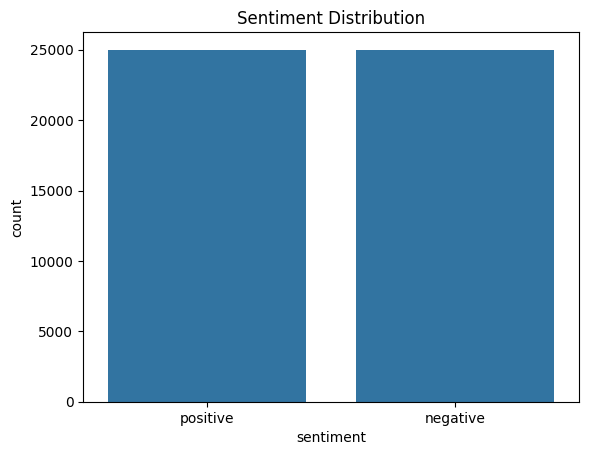

In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nClass distribution:")
print(df["sentiment"].value_counts())

sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["review_clean"] = df["review"].astype(str).apply(clean_text)

In [5]:
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})
assert df["label"].isnull().sum() == 0, "Label mapping failed!"

In [6]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["review_clean"])

X = tokenizer.texts_to_sequences(df["review_clean"])
X = pad_sequences(X, maxlen=max_len)

y = df["label"].values

In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

Up to here everything is the same as the previous models

Build LSTM model

In [8]:
model = Sequential()

# Embedding mayer
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# LSTM layer with regularization
model.add(LSTM(64, dropout=0.3, recurrent_dropout=0.3))

# Dense
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.6))
# Output layyer
model.add(Dense(1, activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train the Model

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 238s 457ms/step - accuracy: 0.7562 - loss: 0.5080 - val_accuracy: 0.8405 - val_loss: 0.3729
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 228s 455ms/step - accuracy: 0.8464 - loss: 0.3790 - val_accuracy: 0.8322 - val_loss: 0.3908
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 229s 457ms/step - accuracy: 0.8726 - loss: 0.3253 - val_accuracy: 0.8629 - val_loss: 0.3511
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 233s 465ms/step - accuracy: 0.8843 - loss: 0.2938 - val_accuracy: 0.8584 - val_loss: 0.3506
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 231s 462ms/step - accuracy: 0.9066 - loss: 0.2453 - val_accuracy: 0.8633 - val_loss: 0.3563


Plot curves

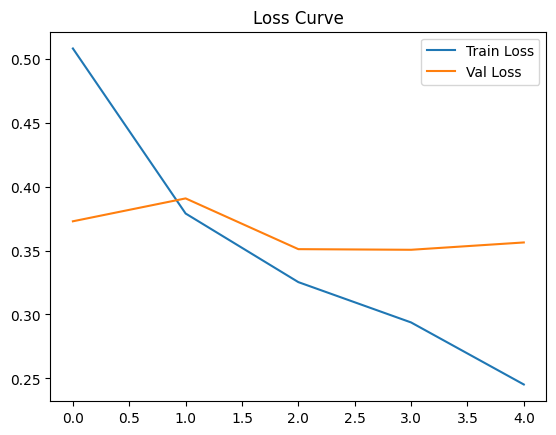

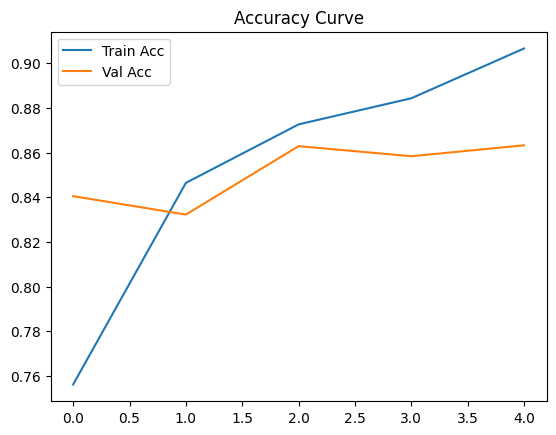

In [15]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

Evaluate the model

In [12]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = np.mean(y_pred.flatten() == y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step
Test Accuracy: 0.8645


Confusion matrix

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      5000
           1       0.85      0.89      0.87      5000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



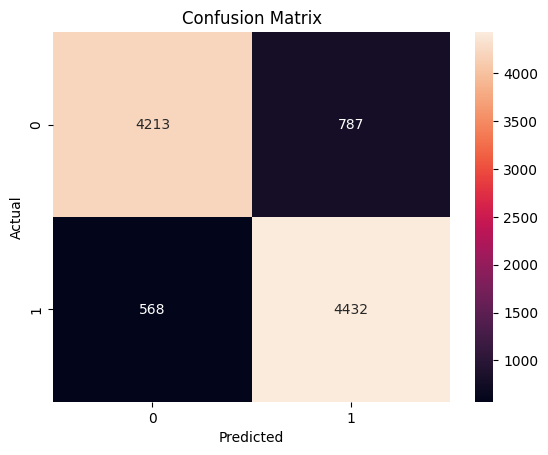

In [13]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Save the results

In [14]:
import os

os.makedirs("results", exist_ok=True)

# Save metrics
with open("results/metrics.txt", "w") as f:
    f.write(classification_report(y_test, y_pred))

# Save confusion matrix
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.savefig("results/confusion_matrix.png")
plt.close()